# Build Harvard–Oxford Connectomes from Real NKI fMRI

This notebook completes the missing step:

```text
real fMRI image → Harvard–Oxford atlas → ROI time series → correlation connectome
```

It saves:

```text
data/processed/harvard_oxford_connectomes.npy
data/processed/harvard_oxford_subjects.csv
data/processed/harvard_oxford_labels.csv
```

Then the Harvard–Oxford Insula–DMN CPM notebook can use those connectomes.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from nilearn import datasets
from nilearn.maskers import NiftiLabelsMasker
from nilearn.connectome import ConnectivityMeasure

print("Imports OK")


Imports OK


In [2]:
# Project paths
PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
PHENO_DIR = DATA_DIR / "phenotypes"

for d in [RAW_DIR, PROCESSED_DIR, PHENO_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Processed dir:", PROCESSED_DIR)


Project root: /home/john-walkey/Data/Research/connectome
Processed dir: /home/john-walkey/Data/Research/connectome/data/processed


## 1. Fetch NKI data

This uses Nilearn's NKI enhanced dataset fetcher.  
First run may take time because it downloads and caches real data.

We start small with `n_subjects=24`.


In [3]:
# Fetch a small real-data sample.
# If this is slow or fails, reduce n_subjects to 10 first.

n_subjects = 24

nki = datasets.fetch_development_fmri(n_subjects=n_subjects)

print("Keys:", nki.keys())
print("Number of functional images:", len(nki.func))
print("Phenotype columns:", nki.phenotypic.columns if hasattr(nki.phenotypic, "columns") else "No dataframe columns")


[fetch_development_fmri] Dataset created in /home/john-walkey/nilearn_data/development_fmri
[fetch_development_fmri] Added README.md to /home/john-walkey/nilearn_data/development_fmri
[fetch_development_fmri] Dataset created in /home/john-walkey/nilearn_data/development_fmri/development_fmri
[fetch_development_fmri] Downloading data from https://osf.io/yr3av/download ...
[fetch_development_fmri]  ...done. (2 seconds, 0 min)

[fetch_development_fmri] Dataset found in /home/john-walkey/nilearn_data/development_fmri/development_fmri
[fetch_development_fmri] Downloading data from https://osf.io/download/5c8ff3e9a743a90017608158/ ...
[fetch_development_fmri]  ...done. (2 seconds, 0 min)

[fetch_development_fmri] Downloading data from https://osf.io/download/5c8ff3e82286e80018c3e443/ ...
[fetch_development_fmri]  ...done. (3 seconds, 0 min)

[fetch_development_fmri] Downloading data from https://osf.io/download/5c8ff3e4a743a9001760814f/ ...
[fetch_development_fmri]  ...done. (2 seconds, 0 mi

In [4]:
# Save phenotypes for later
pheno = nki.phenotypic.copy()
pheno.to_csv(PHENO_DIR / "nki_phenotypes.csv", index=False)

print(pheno.head())
print("Saved:", PHENO_DIR / "nki_phenotypes.csv")


    participant_id    Age AgeGroup Child_Adult Gender Handedness
126   sub-pixar127  23.00    Adult       adult      F          R
124   sub-pixar125  31.00    Adult       adult      M          R
123   sub-pixar124  33.44    Adult       adult      M          R
122   sub-pixar123  27.06    Adult       adult      F          R
125   sub-pixar126  19.00    Adult       adult      F          R
Saved: /home/john-walkey/Data/Research/connectome/data/phenotypes/nki_phenotypes.csv


## 2. Fetch Harvard–Oxford atlas

In [5]:
atlas = datasets.fetch_atlas_harvard_oxford("cort-maxprob-thr25-2mm")

atlas_img = atlas.maps
labels = list(atlas.labels)

label_table = pd.DataFrame({
    "atlas_label_index": range(len(labels)),
    "label": labels
})
label_table.to_csv(PROCESSED_DIR / "harvard_oxford_labels.csv", index=False)

print("Atlas:", atlas_img)
print("Number of labels including background:", len(labels))
print(label_table.head(15))
print("Saved:", PROCESSED_DIR / "harvard_oxford_labels.csv")


[fetch_atlas_harvard_oxford] Dataset found in /home/john-walkey/nilearn_data/fsl
Atlas: 
<class 'nibabel.nifti1.Nifti1Image'>
data shape (91, 109, 91)
affine:
[[   2.    0.    0.  -90.]
 [   0.    2.    0. -126.]
 [   0.    0.    2.  -72.]
 [   0.    0.    0.    1.]]
metadata:
<class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : b''
db_name         : b''
extents         : 0
session_error   : 0
regular         : b'r'
dim_info        : 0
dim             : [  3  91 109  91   1   1   1   1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : uint8
bitpix          : 8
slice_start     : 0
pixdim          : [1. 2. 2. 2. 1. 1. 1. 1.]
vox_offset      : 0.0
scl_slope       : nan
scl_inter       : nan
slice_end       : 0
slice_code      : unknown
xyzt_units      : 10
cal_max         : 48.0
cal_min         : 0.0
slice_duration  : 0.0
toffset         : 0.0
glmax           : 0
glmin           : 0
descr

## 3. Extract ROI time series

This is the slow/real neuroimaging step.

For each subject:
- load fMRI image
- apply Harvard–Oxford atlas
- extract one time series per ROI

The atlas has background + cortical ROIs. Background is ignored by the masker.


In [6]:
masker = NiftiLabelsMasker(
    labels_img=atlas_img,
    standardize=True,
    detrend=True,
    low_pass=None,
    high_pass=None,
    t_r=None,
    verbose=1
)

time_series_list = []
subject_rows = []

for idx, func_file in enumerate(nki.func):
    print(f"\nSubject {idx+1}/{len(nki.func)}")
    print(func_file)

    ts = masker.fit_transform(func_file)
    print("Time series shape:", ts.shape)

    time_series_list.append(ts)
    subject_rows.append({
        "row": idx,
        "func_file": str(func_file)
    })

subjects_df = pd.DataFrame(subject_rows)
subjects_df.to_csv(PROCESSED_DIR / "harvard_oxford_subjects.csv", index=False)

print("\nDone extracting time series")
print("Saved:", PROCESSED_DIR / "harvard_oxford_subjects.csv")



Subject 1/24
/home/john-walkey/nilearn_data/development_fmri/development_fmri/sub-pixar127_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz
[NiftiLabelsMasker.wrapped] Loading regions from <nibabel.nifti1.Nifti1Image object at 0x77dde071db20>
[NiftiLabelsMasker.wrapped] Resampling regions
[NiftiLabelsMasker.wrapped] Finished fit
[NiftiLabelsMasker.wrapped] Loading data from '/home/john-walkey/nilearn_data/development_fmri/development_fmri/sub-pixar127_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz'
[NiftiLabelsMasker.wrapped] Extracting region signals


/tmp/ipykernel_17523/4215200490.py:18: FutureWarning: The 'zscore' strategy incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the 'zscore' option will be removed and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  ts = masker.fit_transform(func_file)


[NiftiLabelsMasker.wrapped] Cleaning extracted signals
Time series shape: (168, 48)

Subject 2/24
/home/john-walkey/nilearn_data/development_fmri/development_fmri/sub-pixar125_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz
[NiftiLabelsMasker.wrapped] Loading regions from <nibabel.nifti1.Nifti1Image object at 0x77dde071db20>
[NiftiLabelsMasker.wrapped] Resampling regions
[NiftiLabelsMasker.wrapped] Finished fit
[NiftiLabelsMasker.wrapped] Loading data from '/home/john-walkey/nilearn_data/development_fmri/development_fmri/sub-pixar125_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz'
[NiftiLabelsMasker.wrapped] Extracting region signals


/tmp/ipykernel_17523/4215200490.py:18: FutureWarning: The 'zscore' strategy incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the 'zscore' option will be removed and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  ts = masker.fit_transform(func_file)


[NiftiLabelsMasker.wrapped] Cleaning extracted signals
Time series shape: (168, 48)

Subject 3/24
/home/john-walkey/nilearn_data/development_fmri/development_fmri/sub-pixar124_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz
[NiftiLabelsMasker.wrapped] Loading regions from <nibabel.nifti1.Nifti1Image object at 0x77dde071db20>
[NiftiLabelsMasker.wrapped] Resampling regions
[NiftiLabelsMasker.wrapped] Finished fit
[NiftiLabelsMasker.wrapped] Loading data from '/home/john-walkey/nilearn_data/development_fmri/development_fmri/sub-pixar124_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz'
[NiftiLabelsMasker.wrapped] Extracting region signals


...

[NiftiLabelsMasker.wrapped] Cleaning extracted signals
Time series shape: (168, 48)

Subject 23/24
/home/john-walkey/nilearn_data/development_fmri/development_fmri/sub-pixar011_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz
[NiftiLabelsMasker.wrapped] Loading regions from <nibabel.nifti1.Nifti1Image object at 0x77dde071db20>
[NiftiLabelsMasker.wrapped] Resampling regions
[NiftiLabelsMasker.wrapped] Finished fit
[NiftiLabelsMasker.wrapped] Loading data from '/home/john-walkey/nilearn_data/development_fmri/development_fmri/sub-pixar011_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz'
[NiftiLabelsMasker.wrapped] Extracting region signals


/tmp/ipykernel_17523/4215200490.py:18: FutureWarning: The 'zscore' strategy incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the 'zscore' option will be removed and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  ts = masker.fit_transform(func_file)


[NiftiLabelsMasker.wrapped] Cleaning extracted signals
Time series shape: (168, 48)

Subject 24/24
/home/john-walkey/nilearn_data/development_fmri/development_fmri/sub-pixar012_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz
[NiftiLabelsMasker.wrapped] Loading regions from <nibabel.nifti1.Nifti1Image object at 0x77dde071db20>
[NiftiLabelsMasker.wrapped] Resampling regions
[NiftiLabelsMasker.wrapped] Finished fit
[NiftiLabelsMasker.wrapped] Loading data from '/home/john-walkey/nilearn_data/development_fmri/development_fmri/sub-pixar012_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz'
[NiftiLabelsMasker.wrapped] Extracting region signals


/tmp/ipykernel_17523/4215200490.py:18: FutureWarning: The 'zscore' strategy incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the 'zscore' option will be removed and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  ts = masker.fit_transform(func_file)


[NiftiLabelsMasker.wrapped] Cleaning extracted signals
Time series shape: (168, 48)

Done extracting time series
Saved: /home/john-walkey/Data/Research/connectome/data/processed/harvard_oxford_subjects.csv


## 4. Build correlation connectomes

In [7]:
correlation_measure = ConnectivityMeasure(kind="correlation")

connectomes = correlation_measure.fit_transform(time_series_list)

print("Connectomes shape:", connectomes.shape)

# clean diagonal for CPM
for c in connectomes:
    np.fill_diagonal(c, 0)

np.save(PROCESSED_DIR / "harvard_oxford_connectomes.npy", connectomes)

print("Saved:", PROCESSED_DIR / "harvard_oxford_connectomes.npy")


Connectomes shape: (24, 48, 48)
Saved: /home/john-walkey/Data/Research/connectome/data/processed/harvard_oxford_connectomes.npy


/tmp/ipykernel_17523/4028063446.py:3: FutureWarning: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the default strategy will be replaced by the new strategy, the 'zscore' option will be removed. and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  connectomes = correlation_measure.fit_transform(time_series_list)
/tmp/ipykernel_17523/4028063446.py:3: FutureWarning: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the default strategy will be replaced by the new strategy, the 'zscore' option will be removed. and using standardize=True will fall back to 'zscore_sample'.T

## 5. Quick sanity checks

Number of subjects: 24
Number of ROIs: 48
Expected Harvard-Oxford ROIs: 48


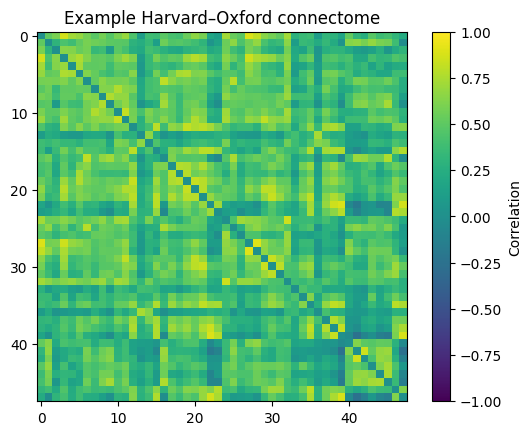

In [8]:
print("Number of subjects:", connectomes.shape[0])
print("Number of ROIs:", connectomes.shape[1])
print("Expected Harvard-Oxford ROIs:", len(labels) - 1)

plt.imshow(connectomes[0], vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.title("Example Harvard–Oxford connectome")
plt.show()


## 6. Next step

Now rerun:

```text
harvard_oxford_insula_dmn_cpm.ipynb
```

It should now find:

```text
data/processed/harvard_oxford_connectomes.npy
```

and proceed further.
